In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy 

data_paths = []
data_paths.append(Path(r"C:\Users\elyse\Downloads\Python\Capstone\capstone_throttleable_engine_2025-26\software\logs\daq\2026\05\29\04-15-33_data.csv"))
data_paths.append(Path(r"C:\Users\elyse\Downloads\Python\Capstone\capstone_throttleable_engine_2025-26\software\logs\daq\2026\05\29\04-18-50_data.csv"))
data_paths.append(Path(r"C:\Users\elyse\Downloads\Python\Capstone\capstone_throttleable_engine_2025-26\software\logs\daq\2026\05\29\04-27-21_data.csv"))

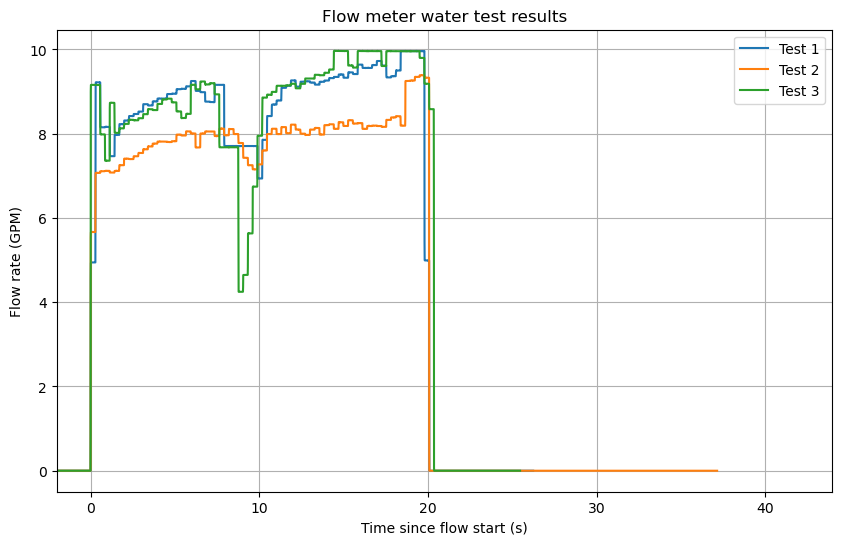

In [3]:
flow_meter_name = "FM-FM"

flow_start_threshold_gpm = 1.0
flow_zero_voltage = 0.8
flow_full_scale_voltage = 4.0
flow_full_scale_gpm = 10.0

def voltage_to_gpm(voltage):
    flow = (voltage - flow_zero_voltage) * flow_full_scale_gpm / (flow_full_scale_voltage - flow_zero_voltage)
    return np.clip(flow, 0.0, None)

df1 = pd.read_csv(data_paths[0])
df1.columns = [str(col).strip() for col in df1.columns]

sensor_df1 = df1[df1["sensor_name"] == flow_meter_name].copy().sort_values("t_wall")
raw_t1 = sensor_df1["t_wall"].to_numpy()
voltage1 = sensor_df1["Voltage 1"].to_numpy()
flow1 = voltage_to_gpm(voltage1)
start_idx1 = np.flatnonzero(flow1 > flow_start_threshold_gpm)
t1_start = raw_t1[start_idx1[0]] if len(start_idx1) else raw_t1.min()
t1 = raw_t1 - t1_start

df2 = pd.read_csv(data_paths[1])
df2.columns = [str(col).strip() for col in df2.columns]

sensor_df2 = df2[df2["sensor_name"] == flow_meter_name].copy().sort_values("t_wall")
raw_t2 = sensor_df2["t_wall"].to_numpy()
voltage2 = sensor_df2["Voltage 1"].to_numpy()
flow2 = voltage_to_gpm(voltage2)
start_idx2 = np.flatnonzero(flow2 > flow_start_threshold_gpm)
t2_start = raw_t2[start_idx2[0]] if len(start_idx2) else raw_t2.min()
t2 = raw_t2 - t2_start

df3 = pd.read_csv(data_paths[2])
df3.columns = [str(col).strip() for col in df3.columns]

sensor_df3 = df3[df3["sensor_name"] == flow_meter_name].copy().sort_values("t_wall")
raw_t3 = sensor_df3["t_wall"].to_numpy()
voltage3 = sensor_df3["Voltage 1"].to_numpy()
flow3 = voltage_to_gpm(voltage3)
start_idx3 = np.flatnonzero(flow3 > flow_start_threshold_gpm)
t3_start = raw_t3[start_idx3[0]] if len(start_idx3) else raw_t3.min()
t3 = raw_t3 - t3_start

plt.figure(figsize=(10, 6))
plt.plot(t1, flow1, label="Test 1")
plt.plot(t2, flow2, label="Test 2")
plt.plot(t3, flow3, label="Test 3")
plt.xlim(left=-2)
plt.xlabel("Time since flow start (s)")
plt.ylabel("Flow rate (GPM)")
plt.title("Flow meter water test results")
plt.legend()
plt.grid(True)
plt.show()


Average flow rate for Test 1: 8.78 GPM
Average flow rate for Test 2: 7.95 GPM
Average flow rate for Test 3: 8.84 GPM
Total volume for Test 1: 176.19 gallons
Total volume for Test 2: 159.61 gallons
Total volume for Test 3: 180.41 gallons
Actual Volume for Test 1: 3.53 gallons
Actual Volume for Test 2: 2.86 gallons
Actual Volume for Test 3: 3.30 gallons
Calibration equation: actual = 0.3681 * measured + -0.0060


Text(0.5, 1.0, 'Flow Meter Calibration')

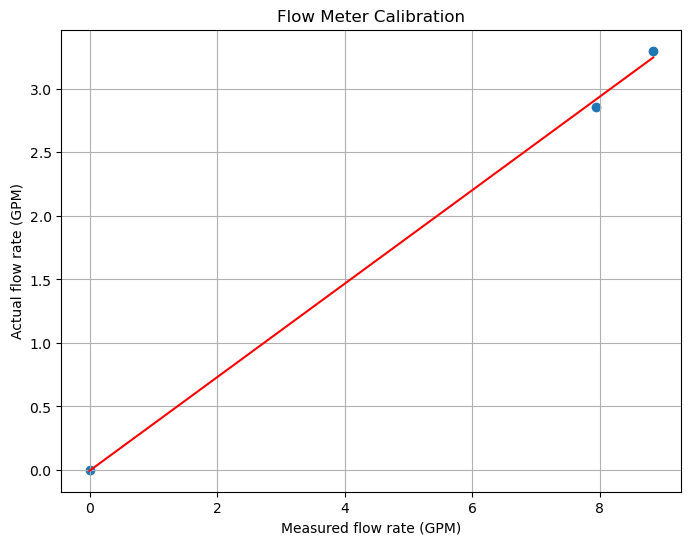

In [4]:
flow1 = flow1[flow1 > 4.0]
flow2 = flow2[flow2 > 4.0]
flow3 = flow3[flow3 > 4.0]

avg_flow1 = np.mean(flow1)
avg_flow2 = np.mean(flow2)
avg_flow3 = np.mean(flow3)
print(f"Average flow rate for Test 1: {avg_flow1:.2f} GPM")
print(f"Average flow rate for Test 2: {avg_flow2:.2f} GPM")
print(f"Average flow rate for Test 3: {avg_flow3:.2f} GPM")

volume1 = np.trapezoid(flow1, t1[:len(flow1)])
volume2 = np.trapezoid(flow2, t2[:len(flow2)])
volume3 = np.trapezoid(flow3, t3[:len(flow3)])
print(f"Total volume for Test 1: {volume1:.2f} gallons")
print(f"Total volume for Test 2: {volume2:.2f} gallons")
print(f"Total volume for Test 3: {volume3:.2f} gallons")

test1_flow = 3.53
test2_flow = 2.86
test3_flow = 3.3
print(f"Actual Volume for Test 1: {test1_flow:.2f} gallons")
print(f"Actual Volume for Test 2: {test2_flow:.2f} gallons")
print(f"Actual Volume for Test 3: {test3_flow:.2f} gallons")

flow_measured = np.array([0, avg_flow2, avg_flow3])
flow_actual = np.array([0, test2_flow, test3_flow])
p = np.polyfit(flow_measured, flow_actual, 1)
print(f"Calibration equation: actual = {p[0]:.4f} * measured + {p[1]:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(flow_measured, flow_actual, label="Data points")
plt.plot(flow_measured, np.polyval(p, flow_measured), color="red", label="Calibration fit")
plt.xlabel("Measured flow rate (GPM)")
plt.grid(True)
plt.ylabel("Actual flow rate (GPM)")
plt.title("Flow Meter Calibration")